In [2]:
!pip install deepspeed mpi4py --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:0000:010:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 4.0 MB/s eta 0:00:00


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# Create datasets for training & validation, download if necessary
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Create data loaders for our datasets; shuffle for training, not for validation
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Report split sizes
print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))

2025-12-24 12:09:04.620408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766578144.823453      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766578144.879281      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766578145.361350      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766578145.361400      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766578145.361403      55 computation_placer.cc:177] computation placer alr

Training set has 60000 instances
Validation set has 10000 instances


Sandal  Ankle Boot  Sneaker  T-shirt/top


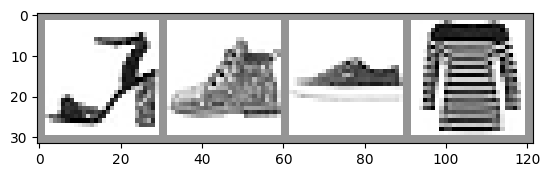

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [5]:
import torch.nn as nn
import torch.nn.functional as F

# PyTorch models inherit from torch.nn.Module
class GarmentClassifier(nn.Module):
    def __init__(self):
        super(GarmentClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = GarmentClassifier()

In [6]:
loss_fn = torch.nn.CrossEntropyLoss()

# NB: Loss functions expect data in batches, so we're creating batches of 4
# Represents the model's confidence in each of the 10 classes for a given input
dummy_outputs = torch.rand(4, 10)
# Represents the correct class among the 10 being tested
dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print('Total loss for this batch: {}'.format(loss.item()))

tensor([[0.3506, 0.9553, 0.4576, 0.4371, 0.9821, 0.0273, 0.6492, 0.0025, 0.9638,
         0.2080],
        [0.2775, 0.8056, 0.0588, 0.4731, 0.8005, 0.1367, 0.1427, 0.3018, 0.1337,
         0.7272],
        [0.3252, 0.5063, 0.9375, 0.5389, 0.1080, 0.0568, 0.4483, 0.8068, 0.0719,
         0.4449],
        [0.4679, 0.2051, 0.7479, 0.3326, 0.8407, 0.5741, 0.2424, 0.5545, 0.1352,
         0.3032]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.2371866703033447


In [7]:
# Optimizers specified in the torch.optim package
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [8]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

In [9]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 1.578241197437048
  batch 2000 loss: 0.80124330735486
  batch 3000 loss: 0.6628279231890337
  batch 4000 loss: 0.6188101671640761
  batch 5000 loss: 0.5838394125299529
  batch 6000 loss: 0.5260942607820034
  batch 7000 loss: 0.5531201288489392
  batch 8000 loss: 0.5022876053857617
  batch 9000 loss: 0.5290208444480086
  batch 10000 loss: 0.4639566261111759
  batch 11000 loss: 0.4526016560756834
  batch 12000 loss: 0.41524382020591294
  batch 13000 loss: 0.4172608152522007
  batch 14000 loss: 0.42520245824207087
  batch 15000 loss: 0.4095323635129025
LOSS train 0.4095323635129025 valid 0.41994452476501465
EPOCH 2:
  batch 1000 loss: 0.3885129421011661
  batch 2000 loss: 0.39291074126795866
  batch 3000 loss: 0.3762820850403514
  batch 4000 loss: 0.3886391246415442
  batch 5000 loss: 0.3750456336691277
  batch 6000 loss: 0.3825707764403196
  batch 7000 loss: 0.39404332407185577
  batch 8000 loss: 0.3654414317016781
  batch 9000 loss: 0.39257557074556826
  batc

In [22]:
%%writefile ds_config.json
{
  "train_batch_size": 16,
  "gradient_accumulation_steps": 1,

  "fp16": {
    "enabled": true
  },

  "zero_optimization": {
    "stage": 0
  },

  "distributed_training": {
    "enabled": true
  }
}


Overwriting ds_config.json


In [23]:
# import deepspeed
# model_engine, optimizer, _, _ = deepspeed.initialize(
#     args=None,                       # 🔴 FIX HERE
#     model=model,
#     model_parameters=model.parameters(),
#     config="ds_config.json"          # REQUIRED if args=None
# )


In [24]:
# for step, batch in enumerate(data_loader):
#     #forward() method
#     loss = model_engine(batch)

#     #runs backpropagation
#     model_engine.backward(loss)

#     #weight update
#     model_engine.step()

In [29]:
load_dir = "/kaggle/working/model_20251224_115252_4"      # folder where DS checkpoints exist
save_dir = "/kaggle/working/checkpoints"
save_interval = 100           # steps


In [32]:
def dataloader_to_step(dataloader, step):
    it = iter(dataloader)
    for _ in range(step):
        try:
            next(it)
        except StopIteration:
            break
    return it


In [50]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

model_engine, optimizer, _, _ = deepspeed.initialize(
    args=None,
    model=model,
    optimizer=optimizer,
    model_parameters=model.parameters(),
    config="ds_config.json"
)


In [55]:
_, client_sd = model_engine.load_checkpoint(load_dir)

if client_sd is None:
    start_step = 0
else:
    start_step = client_sd.get("step", 0)

print("Resuming from step:", start_step)

print("Resuming from step:", start_step)
#load checkpoint
# _, client_sd = model_engine.load_checkpoint(load_dir)
# step = client_sd['step']

#advance data loader to ckpt step
train_iter=dataloader_to_step(training_loader, start_step)

for step, batch in enumerate(train_iter, start=start_step):

    # move batch to device if needed
    if isinstance(batch, (list, tuple)):
        batch = [b.to(model_engine.device) for b in batch]
    else:
        batch = batch.to(model_engine.device)

    # forward
    inputs, labels = batch
    inputs = inputs.to(
    device=model_engine.device,
    dtype=next(model_engine.parameters()).dtype
)
    labels = labels.to(
    device=model_engine.device,
    dtype=next(model_engine.parameters()).dtype
)
    loss = model_engine(inputs).mean()
    # loss = model_engine(batch)

    # backward + step
    model_engine.backward(loss)
    model_engine.step()

    # save checkpoint
    if step % save_interval == 0:
        model_engine.save_checkpoint(
            save_dir,
            tag=f"step_{step}",
            client_state={"step": step}
        )

    print(f"Step {step}, loss={loss.item()}")

        

[2025-12-24 12:41:15,533] [WARNING] [engine.py:3294:load_checkpoint] Unable to find latest file at /kaggle/working/model_20251224_115252_4/latest, if trying to load latest checkpoint please ensure this file exists or pass an explicit checkpoint tag when loading a checkpoint.
Resuming from step: 0
Resuming from step: 0
Step 0, loss=0.06793212890625
Step 1, loss=0.0679931640625
Step 2, loss=-0.07080078125
Step 3, loss=-0.171630859375
Step 4, loss=-0.2158203125
Step 5, loss=-0.3876953125
Step 6, loss=-0.5361328125
Step 7, loss=-0.392333984375
Step 8, loss=-0.68212890625
Step 9, loss=-0.85888671875
Step 10, loss=-1.0478515625
Step 11, loss=-0.66162109375
Step 12, loss=-1.990234375
Step 13, loss=-1.3818359375
Step 14, loss=-1.9111328125
Step 15, loss=-2.318359375
Step 16, loss=-2.00390625
Step 17, loss=-3.265625
Step 18, loss=-3.73828125
Step 19, loss=-3.94140625
Step 20, loss=-4.16796875
Step 21, loss=-5.40625
Step 22, loss=-9.3515625
Step 23, loss=-10.265625
Step 24, loss=-9.9140625
Step 